In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

In [24]:
# 2.1 理论计算题 定义向量和矩阵
a = np.array([2, -1, 3]).T
b = np.array([1, 4, -2]).T
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

# 1. 向量点积 a·b
dot_product = np.dot(a, b)
print("1. 向量点积a·b =", dot_product)

# 2. 矩阵乘法 A×B 及形状
A_mul_B = np.matmul(A, B)
print("\n2. 矩阵乘法A×B结果：")
print(A_mul_B)
print("结果矩阵形状：", A_mul_B.shape)

# 3. 向量a的Frobenius范数
a_fro = np.linalg.norm(a)
print("\n3. 向量a的Frobenius范数 =", a_fro)
print("sqrt(14) ≈", np.sqrt(14))

1. 向量点积a·b = -8

2. 矩阵乘法A×B结果：
[[ 8  5]
 [ 1 -2]]
结果矩阵形状： (2, 2)

3. 向量a的Frobenius范数 = 3.7416573867739413
sqrt(14) ≈ 3.7416573867739413


In [25]:
#2.2 编程题 
# 1. 创建3×4的标准正态分布随机矩阵X
X = np.random.randn(3, 4)
print("1. 3×4标准正态分布矩阵X：")
print(X)

# 2. 创建4×2的全1矩阵Y
Y = np.ones((4, 2))
print("\n2. 4×2全1矩阵Y：")
print(Y)

# 3. 计算矩阵乘法Z = X × Y
Z = np.matmul(X, Y)
print("\n3. 矩阵乘法结果Z：")
print(Z)

# 4. 输出Z的第一行第二列元素、第二行所有元素
# 注：Python为0索引，第一行=索引0，第二列=索引1；第二行=索引1
target_element = Z[0, 1]
second_row = Z[1, :]
print(f"\n4. Z第一行第二列元素：{target_element}")
print(f"Z第二行所有元素：{second_row}")

# 5. 计算Z的Frobenius范数
Z_fro = np.linalg.norm(Z, 'fro')
print(f"\n5. Z的Frobenius范数：{Z_fro}")

1. 3×4标准正态分布矩阵X：
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 4×2全1矩阵Y：
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵乘法结果Z：
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z第一行第二列元素：2.5291682463487657
Z第二行所有元素：[1.87835721 1.87835721]

5. Z的Frobenius范数：4.616873319476864


In [26]:
# 3.1 理论计算题（贝叶斯公式，代码验证）
# 定义概率
P_A = 0.001  # 患病率
P_notA = 1 - P_A  # 未患病概率
P_B_A = 0.99  # 患病检测阳性概率（灵敏度）
P_B_notA = 0.02  # 未患病检测阳性概率（假阳性率）

# 贝叶斯公式计算 P(A|B)
P_A_B = (P_B_A * P_A) / (P_B_A * P_A + P_B_notA * P_notA)
print(f"检测阳性时真正患病的概率：{P_A_B:.4f}，即 {P_A_B*100:.2f}%")

检测阳性时真正患病的概率：0.0472，即 4.72%


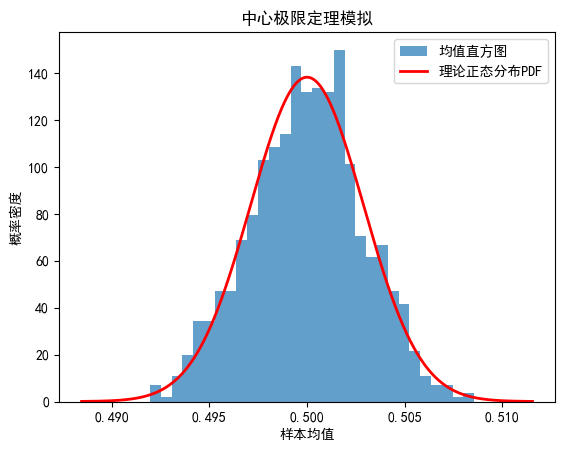

均值的实际方差：0.00000831
均值的理论方差：0.00000833


In [27]:
#3.2 编程题（中心极限定理模拟）
# 1. 生成数据并计算均值
n = 10000  # 单次均匀分布样本数
m = 1000   # 重复实验次数
# 生成m×n的均匀分布矩阵，每行计算均值
uniform_data = np.random.uniform(0, 1, size=(m, n))
mean_values = np.mean(uniform_data, axis=1)

# 2. 绘制直方图+理论正态分布PDF
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False

# 理论分布参数：U(0,1)均值μ=0.5，方差σ²=1/12；n个样本均值的分布为N(μ, σ²/n)
mu_theory = 0.5
sigma_theory = np.sqrt(1 / (12 * n))

# 绘制直方图
plt.hist(mean_values, bins=30, density=True, alpha=0.7, label='均值直方图')

# 叠加理论正态分布PDF
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 1000)
pdf_theory = 1 / (sigma_theory * np.sqrt(2 * np.pi)) * np.exp(-(x - mu_theory)**2 / (2 * sigma_theory**2))
plt.plot(x, pdf_theory, 'r-', linewidth=2, label='理论正态分布PDF')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理模拟')
plt.legend()
plt.show()

# 3. 计算实际方差
var_actual = np.var(mean_values)
var_theory = 1 / (12 * n)
print(f"均值的实际方差：{var_actual:.8f}")
print(f"均值的理论方差：{var_theory:.8f}")

In [28]:
#4.1 理论计算题（代码验证）
# 常数定义
x1 = 2
x2 = 1
y = 3
w1 = 0.5
w2 = 1

# 1. 偏导数表达式
# ∂z/∂w1 = 2*(w1x1 + w2x2 - y) * x1
# ∂z/∂w2 = 2*(w1x1 + w2x2 - y) * x2

# 2. 计算梯度值
inner = w1 * x1 + w2 * x2 - y
dz_dw1 = 2 * inner * x1
dz_dw2 = 2 * inner * x2
print(f"∂z/∂w1 = {dz_dw1}")
print(f"∂z/∂w2 = {dz_dw2}")

∂z/∂w1 = -4.0
∂z/∂w2 = -2.0


In [29]:
#4.2 编程题（手动反向传播 + 自动微分验证）
#  给定参数
x = 2
w1 = 1.5
w2 = 0.5

# ========== 1. 手动前向计算 ==========
a = x * w1
b = a + w2
L = b ** 2
print(f"前向计算结果L = {L}")

# ========== 2. 手动反向传播（链式法则） ==========
dL_db = 2 * b
db_dw1 = x
db_dw2 = 1
dL_dw1_manual = dL_db * db_dw1
dL_dw2_manual = dL_db * db_dw2
print(f"\n手动计算梯度：")
print(f"dL/dw1 = {dL_dw1_manual}")
print(f"dL/dw2 = {dL_dw2_manual}")

# ========== 3. PyTorch自动微分验证 ==========
# 定义带梯度的张量
w1_torch = torch.tensor(w1, requires_grad=True)
w2_torch = torch.tensor(w2, requires_grad=True)
x_torch = torch.tensor(x)

# 前向计算
a_torch = x_torch * w1_torch
b_torch = a_torch + w2_torch
L_torch = b_torch ** 2

# 反向传播
L_torch.backward()

print(f"\nPyTorch自动微分梯度：")
print(f"dL/dw1 = {w1_torch.grad.item()}")
print(f"dL/dw2 = {w2_torch.grad.item()}")
print(f"\n梯度是否一致：dL/dw1={dL_dw1_manual == w1_torch.grad.item()}, dL/dw2={dL_dw2_manual == w2_torch.grad.item()}")

前向计算结果L = 12.25

手动计算梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch自动微分梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

梯度是否一致：dL/dw1=True, dL/dw2=True


In [30]:
#五、线性方法、基础优化和 softmax 回归
#  ========== 1. 加载并预处理数据 ==========
# 加载MNIST手写数字数据集
digits = load_digits()
X = digits.data  # 形状(1797, 64)，8×8图像展平为64维向量
y = digits.target.reshape(-1, 1)  # 标签(1797, 1)

# 标签one-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 数据归一化
X_train = X_train / 16.0  # 像素值0-16，归一化到0-1
X_test = X_test / 16.0

# ========== 2. 定义核心函数 ==========
def softmax(X):
    # 数值稳定：减去每行最大值，防止指数溢出
    X_max = np.max(X, axis=1, keepdims=True)
    exp_X = np.exp(X - X_max)
    return exp_X / np.sum(exp_X, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # 防止log(0)，添加极小值
    eps = 1e-10
    return -np.sum(y_true * np.log(y_pred + eps)) / y_pred.shape[0]

# ========== 3. 模型初始化 ==========
n_features = X_train.shape[1]  # 64维特征
n_classes = y_train.shape[1]    # 10个分类
W = np.random.randn(n_features, n_classes) * 0.01  # 权重矩阵
b = np.zeros((1, n_classes))  # 偏置

# 超参数
batch_size = 32
lr = 0.1
epochs = 100
n_samples = X_train.shape[0]

# ========== 4. 小批量SGD训练 ==========
for epoch in range(epochs):
    # 打乱训练数据
    shuffle_idx = np.random.permutation(n_samples)
    X_shuffled = X_train[shuffle_idx]
    y_shuffled = y_train[shuffle_idx]
    
    # 小批量迭代
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        batch_n = X_batch.shape[0]
        
        # 前向传播
        logits = np.dot(X_batch, W) + b
        y_pred = softmax(logits)
        
        # 计算梯度
        dW = np.dot(X_batch.T, (y_pred - y_batch)) / batch_n
        db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / batch_n
        
        # 参数更新
        W -= lr * dW
        b -= lr * db
    
    # 每10个epoch打印训练损失
    if (epoch + 1) % 10 == 0:
        train_logits = np.dot(X_train, W) + b
        train_pred = softmax(train_logits)
        train_loss = cross_entropy_loss(train_pred, y_train)
        print(f"Epoch {epoch+1}/{epochs}, 训练损失: {train_loss:.4f}")

# ========== 5. 测试集准确率计算 ==========
test_logits = np.dot(X_test, W) + b
test_pred = softmax(test_logits)
# 转换为类别标签
test_pred_label = np.argmax(test_pred, axis=1)
test_true_label = np.argmax(y_test, axis=1)
# 计算准确率
accuracy = accuracy_score(test_true_label, test_pred_label)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")

Epoch 10/100, 训练损失: 0.4390
Epoch 20/100, 训练损失: 0.2942
Epoch 30/100, 训练损失: 0.2370
Epoch 40/100, 训练损失: 0.2049
Epoch 50/100, 训练损失: 0.1837
Epoch 60/100, 训练损失: 0.1680
Epoch 70/100, 训练损失: 0.1561
Epoch 80/100, 训练损失: 0.1464
Epoch 90/100, 训练损失: 0.1383
Epoch 100/100, 训练损失: 0.1316

测试集准确率: 96.94%


Epoch 20/200, 训练损失: 0.014872
Epoch 40/200, 训练损失: 0.010627
Epoch 60/200, 训练损失: 0.008701
Epoch 80/200, 训练损失: 0.007548
Epoch 100/200, 训练损失: 0.006759
Epoch 120/200, 训练损失: 0.006174
Epoch 140/200, 训练损失: 0.005717
Epoch 160/200, 训练损失: 0.005346
Epoch 180/200, 训练损失: 0.005038
Epoch 200/200, 训练损失: 0.004775

测试集分类准确率: 100.00%


C:\Users\wxd\AppData\Local\Temp\ipykernel_45700\2378228379.py:100: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, grid_y, levels=[0.5], colors='red', linewidths=2, label='决策边界')


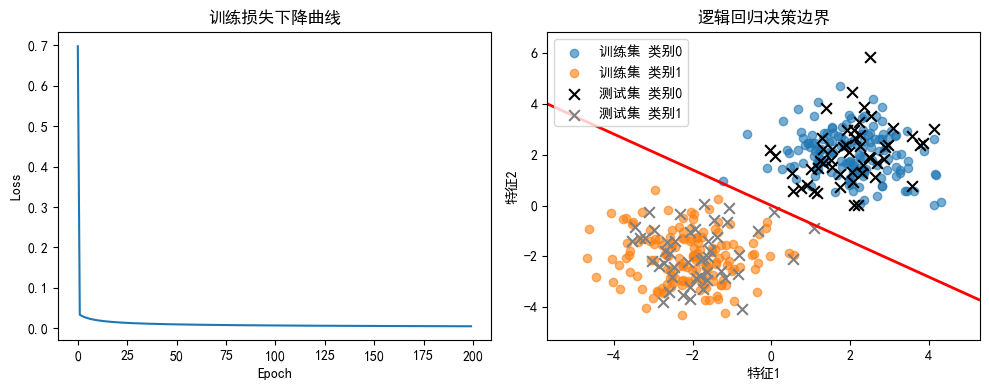

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ========== 1. 手动生成完全线性可分的数据（更可控） ==========
np.random.seed(42)
# 类别0：均值在 [2, 2]
X0 = np.random.randn(200, 2) + np.array([2, 2])
y0 = np.zeros((200, 1))
# 类别1：均值在 [-2, -2]
X1 = np.random.randn(200, 2) + np.array([-2, -2])
y1 = np.ones((200, 1))

# 合并数据
X = np.vstack([X0, X1])
y = np.vstack([y0, y1])

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ========== 2. 定义核心函数 ==========
def sigmoid(z):
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-10
    return -np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)) / y_pred.shape[0]

# ========== 3. 模型初始化 ==========
n_features = X_train.shape[1]
w = np.random.randn(n_features, 1) * 0.01
b = 0.0

# 超参数
lr = 1.0  # 增大学习率，数据简单可以用大一点
epochs = 200
n_samples = X_train.shape[0]

# ========== 4. 梯度下降训练 ==========
loss_history = []
for epoch in range(epochs):
    # 前向传播
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y_train)
    loss_history.append(loss)
    
    # 计算梯度
    dw = np.dot(X_train.T, (y_pred - y_train)) / n_samples
    db = np.sum(y_pred - y_train) / n_samples
    
    # 参数更新
    w -= lr * dw
    b -= lr * db
    
    # 每20次迭代打印损失
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, 训练损失: {loss:.6f}")

# ========== 5. 测试集准确率 ==========
z_test = np.dot(X_test, w) + b
y_pred_test = sigmoid(z_test)
y_pred_label = (y_pred_test >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_label)
print(f"\n测试集分类准确率: {accuracy * 100:.2f}%")

# ========== 6. 修正后的绘图代码 ==========
plt.figure(figsize=(10, 4))

# 子图1：损失曲线
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('训练损失下降曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 子图2：决策边界
plt.subplot(1, 2, 2)
# 绘制训练样本
plt.scatter(X_train[y_train[:,0]==0, 0], X_train[y_train[:,0]==0, 1], label='训练集 类别0', alpha=0.6)
plt.scatter(X_train[y_train[:,0]==1, 0], X_train[y_train[:,0]==1, 1], label='训练集 类别1', alpha=0.6)

# 绘制测试样本（修正了这里的索引逻辑！）
plt.scatter(X_test[y_test[:,0]==0, 0], X_test[y_test[:,0]==0, 1], marker='x', label='测试集 类别0', c='black', s=60)
plt.scatter(X_test[y_test[:,0]==1, 0], X_test[y_test[:,0]==1, 1], marker='x', label='测试集 类别1', c='gray', s=60)

# 生成网格绘制决策边界
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                        np.arange(x2_min, x2_max, 0.02))
grid_X = np.c_[xx1.ravel(), xx2.ravel()]
grid_z = np.dot(grid_X, w) + b
grid_y = sigmoid(grid_z).reshape(xx1.shape)

# 绘制决策边界
plt.contour(xx1, xx2, grid_y, levels=[0.5], colors='red', linewidths=2, label='决策边界')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('逻辑回归决策边界')
plt.legend()

plt.tight_layout()
plt.show()